# Assignment 5 — NYC Yellow Taxi EDA & Performance Benchmarking

**Matic Zadobovšek and Matija Bažec**


---
## 1  Data Pipeline (Assignment 3 recap)

### 1.1  Ingestion with Dask + SLURM

Raw monthly Parquet files (2020–2024) were loaded with Dask on a SLURM cluster,
schema-normalised (column renames, dtype alignment across years), and written to
three output formats for experimentation: **multi-partition CSV**, **HDF5**, and
an optimised **Hive-partitioned Parquet** (partitioned by `year`).


In [ ]:
# Schema normalisation applied to every monthly file
def fix_schema(df):
    if "Airport_fee" in df.columns:
        df = df.rename(columns={"Airport_fee": "airport_fee"})
    if "airport_fee" not in df.columns:
        df["airport_fee"] = 0.0
    # Align dtypes that differ across year-cohorts
    for col, dtype in [("VendorID","int64"), ("PULocationID","int64"),
                       ("DOLocationID","int64"), ("airport_fee","float64"),
                       ("passenger_count","float64"), ("RatecodeID","float64")]:
        if col in df.columns:
            df[col] = df[col].astype(dtype)
    df = df[expected_columns]
    return df

# Dask + SLURMCluster — workers run on compute nodes
cluster = SLURMCluster(queue="all", processes=1, cores=4,
                       memory="12GB", walltime="04:00:00")
client  = Client(cluster)
cluster.scale(jobs=4)

df_5y = dd.concat([load_year(y) for y in [2020,2021,2022,2023,2024]])
df_5y.to_parquet(parquet_dir, partition_on=["year"],
                 compression="snappy", write_metadata_file=True)


### 1.2  Data Augmentation

Each trip was enriched with external sources joined on date and location:

| Enrichment | Join key | Columns added |
|---|---|---|
| Open-Meteo daily weather | `pickup_date` | `temp_max_c`, `temp_min_c`, `precipitation_mm`, `windspeed_max` |
| TLC zone lookup | `PULocationID` / `DOLocationID` | `Borough_PU/DO`, `Zone_PU/DO`, `service_zone_PU/DO` |
| NYC permitted events | `pickup_date` × borough | `active_PU_events`, `active_DO_events` |
| Schools | dropoff borough | `school_count` |
| Attractions | dropoff borough | `attraction_count` |


Output: `parquet_augmented/` — 60 Parquet files, Hive-partitioned by `year`.


---
## 2  Exploratory Data Analysis

The EDA was executed with **Pandas** for aggregate queries and
**Dask** (distributed, 6 SLURM workers) for the full-dataset scans.
A 0.5 % random sample was drawn once for visualisations that would otherwise
require loading 174 M rows into the scheduler.


### 2.1  Data Quality

In [ ]:
# Null counts across all enriched columns
dq

,null_count,null_pct%
airport_fee,37059380,21.21
passenger_count,9057553,5.18
RatecodeID,9057553,5.18
store_and_fwd_flag,9057553,5.18
congestion_surcharge,9057553,5.18
service_zone_DO,1853246,1.06
service_zone_PU,1692592,0.97
Zone_PU,1355321,0.78
Zone_DO,1209992,0.69
Borough_DO,643254,0.37


**Observations:**
- `airport_fee` is null for 21 % of trips — only added in 2022, absent for pre-2022 rows.
- `passenger_count`, `RatecodeID`, `store_and_fwd_flag` share a ~5 % null rate, likely
  from the same batch of vendor records.
- Weather/zone columns have negligible nulls (< 1 %).

A cleaning step removed 205 947 rows (0.12 %) with erroneous timestamps
(years 2001, 2026, 2098) and extreme outlier fares/distances before visualisation.


### 2.2  Descriptive Statistics (full 174 M rows)

In [ ]:
ss

,fare_amount,trip_distance,trip_duration_min,passenger_count,total_amount,tip_amount,tolls_amount
count,"174,483,497.00","174,483,497.00","174,483,497.00","165,432,622.00","174,483,497.00","174,483,497.00","174,483,497.00"
mean,16.32,3.32,15.48,1.39,23.75,2.88,0.49
std,16.16,4.35,13.29,0.95,78.36,3.58,2.04
min,-499.99,0.00,-59.98,0.00,-559.00,-493.22,-117.26
25%,9.30,1.12,8.08,1.00,15.36,1.00,0.00
50%,13.50,1.91,13.55,1.00,21.00,2.80,0.00
75%,23.30,3.69,22.13,2.00,31.44,4.45,0.00
max,499.99,488.00,599.97,112.00,"1,000,003.80","4,174.00","1,702.88"


**Key figures:**
- Median fare: **$13.50**, mean: **$16.32** — the positive skew reflects airport/long-distance trips.
- Median trip distance: **1.91 miles**, mean: **3.32 miles**.
- Median duration: **13.5 min**, mean: **15.5 min**.
- Negative fares/totals exist (refunds, corrections) — kept in raw data but noted as outliers.


### 2.3  Distributions (0.5 % sample, ~870 K trips)

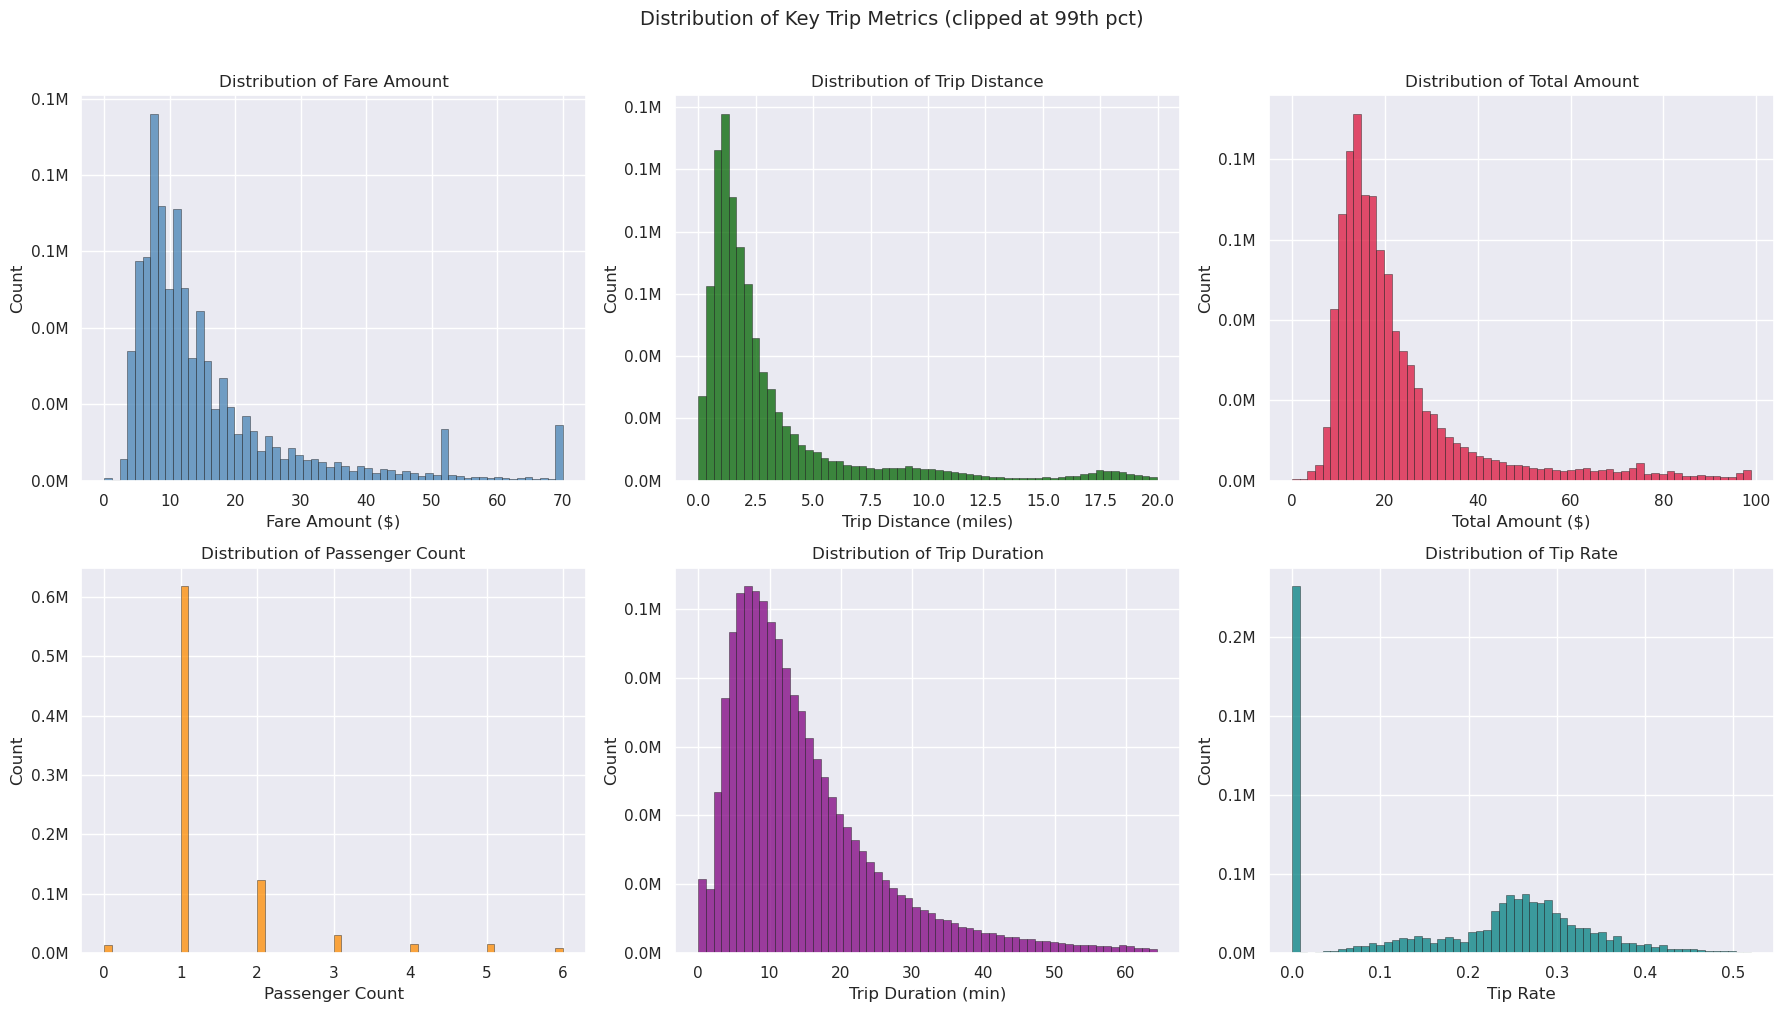

In [ ]:
# Sampled once to avoid 174-M-row compute calls
viz_df = df.sample(frac=0.005, random_state=42).compute()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
viz_df["fare_amount"].clip(-20, 100).hist(bins=60, ax=axes[0,0])
viz_df["trip_distance"].clip(0, 30).hist(bins=60, ax=axes[0,1])
viz_df["trip_duration_min"].clip(0, 90).hist(bins=60, ax=axes[0,2])
...


### 2.4  Temporal Patterns

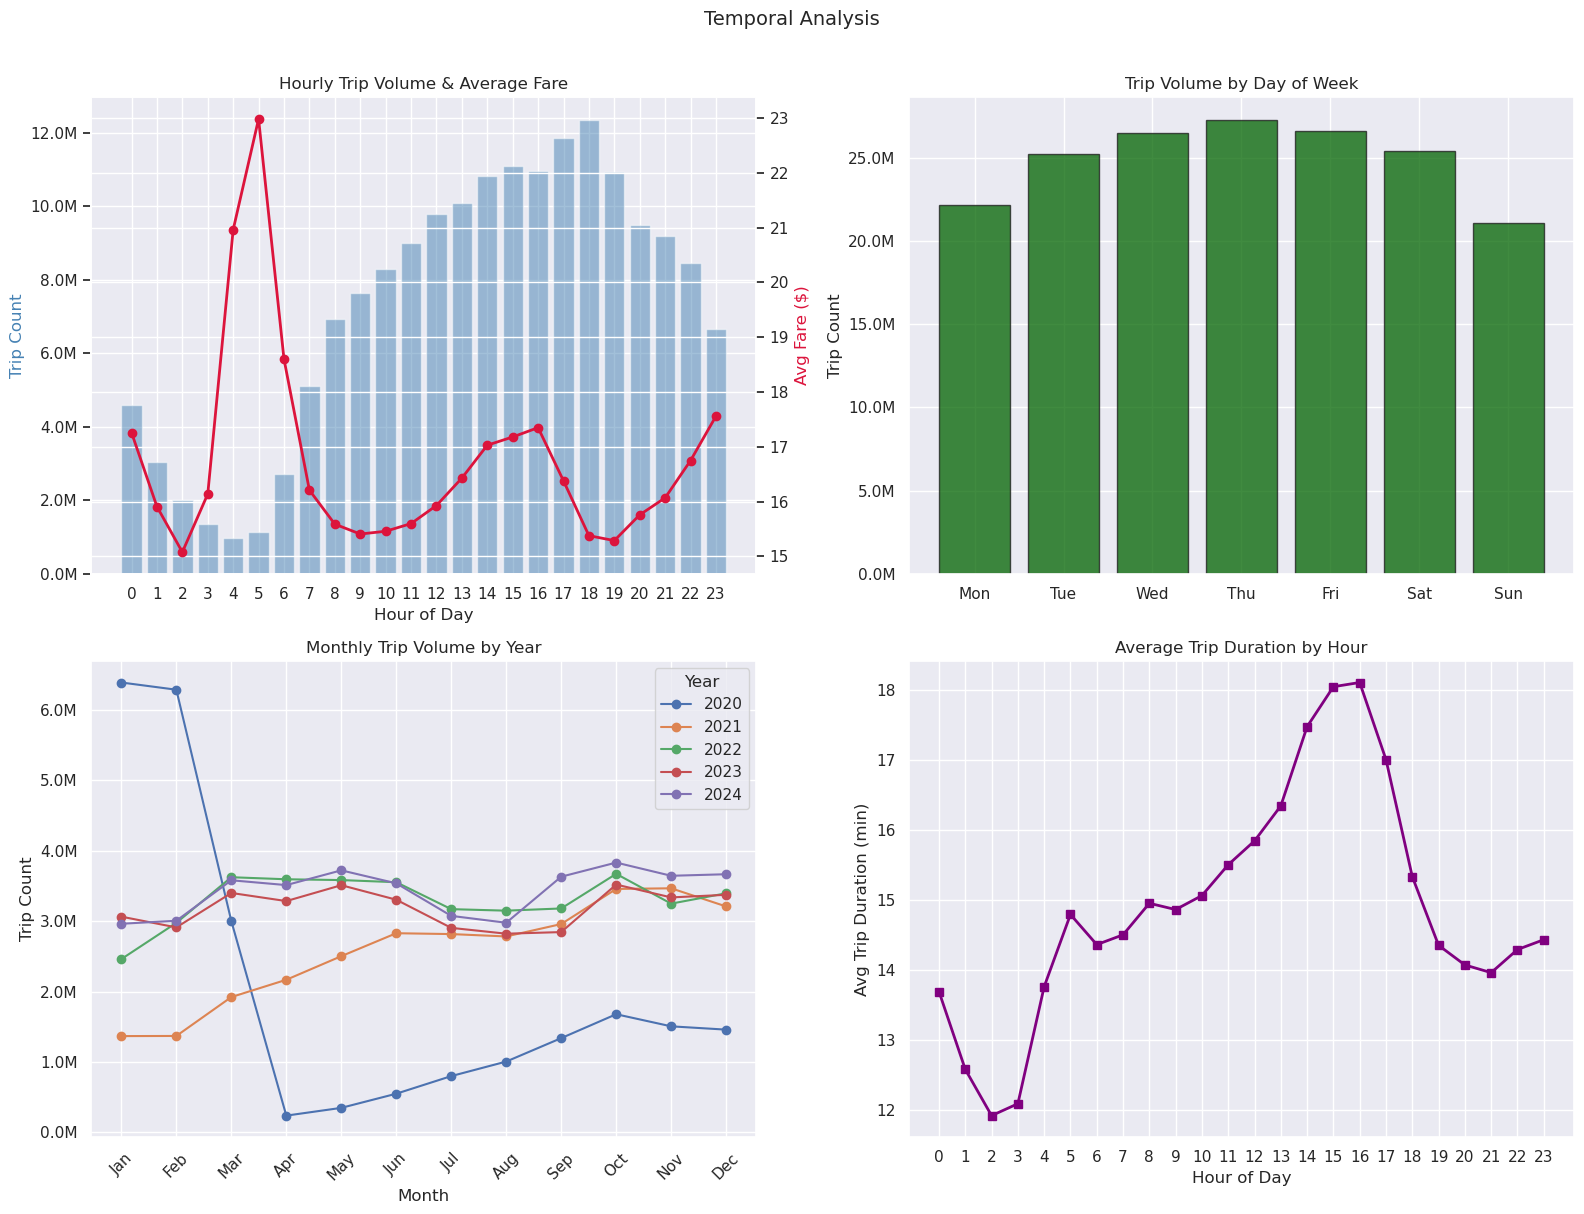

In [ ]:
hourly = df.groupby("pickup_hour").agg(
    trips=("fare_amount","count"), avg_fare=("fare_amount","mean"),
    avg_distance=("trip_distance","mean"), avg_duration=("trip_duration_min","mean")
).compute()

monthly = df.groupby(["pickup_year","pickup_month"]).agg(...).compute()


**Hourly aggregates (all years):**

In [ ]:
tmh

,pickup_hour,trips,avg_fare,avg_distance,avg_duration
0,0,4603341,17.26,3.90,13.69
1,1,3039101,15.91,3.53,12.58
2,2,2008683,15.08,3.31,11.92
3,3,1341717,16.14,3.63,12.09
4,4,974354,20.96,5.00,13.76
5,5,1123637,22.98,5.81,14.79
6,6,2715856,18.60,4.57,14.36
7,7,5097327,16.21,3.57,14.50
8,8,6935581,15.59,3.12,14.95
9,9,7650444,15.41,3.02,14.86


**Observations:**
- Evening peak at 18:00–20:00; morning peak 08:00–09:00.
- COVID-19 is clearly visible: April–June 2020 volume collapsed by ~95 %.
- Recovery is steady through 2021; fares trend upward from 2022 (inflation + fare increases).
- 2024 monthly volumes match pre-pandemic 2019 levels.


**Monthly aggregates (2024 only):**

In [ ]:
tmm[tmm['pickup_year']==2024]

,pickup_year,pickup_month,trips,avg_fare,avg_distance,total_revenue
0,2024,1,2962877,18.16,3.23,"79,365,347.17"
1,2024,2,3005803,18.04,3.15,"79,991,762.51"
2,2024,3,3580683,18.68,3.28,"97,087,577.10"
3,2024,4,3512279,18.96,3.35,"96,536,489.68"
4,2024,5,3721839,19.63,3.39,"105,188,247.24"
5,2024,6,3537181,19.41,3.38,"98,750,269.12"
6,2024,7,3075052,19.52,3.54,"86,328,099.26"
7,2024,8,2977405,19.70,3.61,"84,116,466.55"
8,2024,9,3631293,19.99,3.46,"103,600,262.99"
9,2024,10,3832009,19.71,3.42,"108,912,200.91"


### 2.5  Spatial Patterns

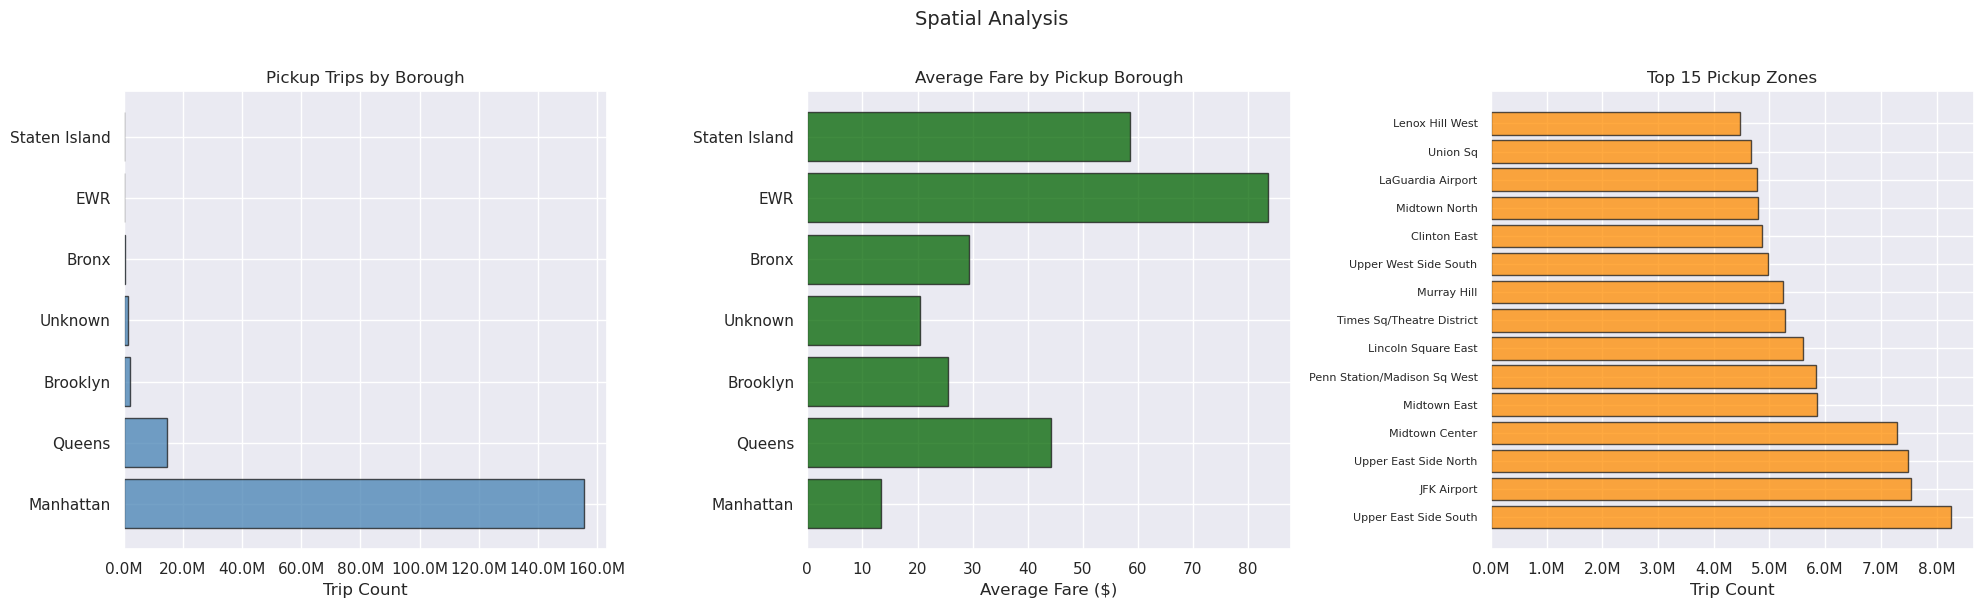

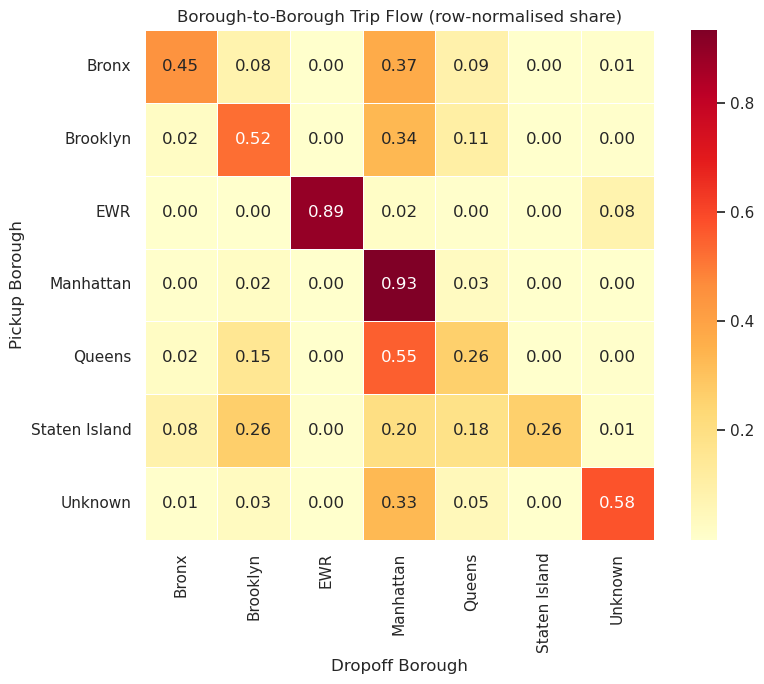

In [ ]:
borough_pu = df.groupby("Borough_PU").agg(
    trips=("fare_amount","count"), avg_fare=("fare_amount","mean"),
    avg_distance=("trip_distance","mean"), avg_total=("total_amount","mean")
).compute()


**Pickup borough breakdown:**

In [ ]:
bpu

,Borough_PU,trips,avg_fare,avg_distance,avg_total
0,Manhattan,155703656,13.41,2.44,20.14
1,Queens,14596126,44.26,12.10,59.67
2,Brooklyn,1929592,25.60,5.39,30.31
3,Unknown,1353800,20.37,4.39,28.41
4,Bronx,522576,29.42,6.56,33.71
5,EWR,26276,83.54,0.98,98.61
6,Staten Island,14903,58.61,16.83,70.85


**Observations:**
- **Manhattan dominates** with 89 % of all pickups but the lowest average fare ($13.41),
  consistent with short cross-town trips.
- **Queens** has the second highest volume and a $44 avg fare, driven by JFK/LGA airport runs.
- **EWR** (Newark) has only 26 K pickups but an $83 avg fare — essentially all airport rides.
- The flow heatmap shows Manhattan→Manhattan as the single dominant corridor,
  with Queens→Manhattan and Manhattan→Queens as secondary flows.


### 2.6  Enriched Data Analysis — Weather, Events, Schools, Attractions

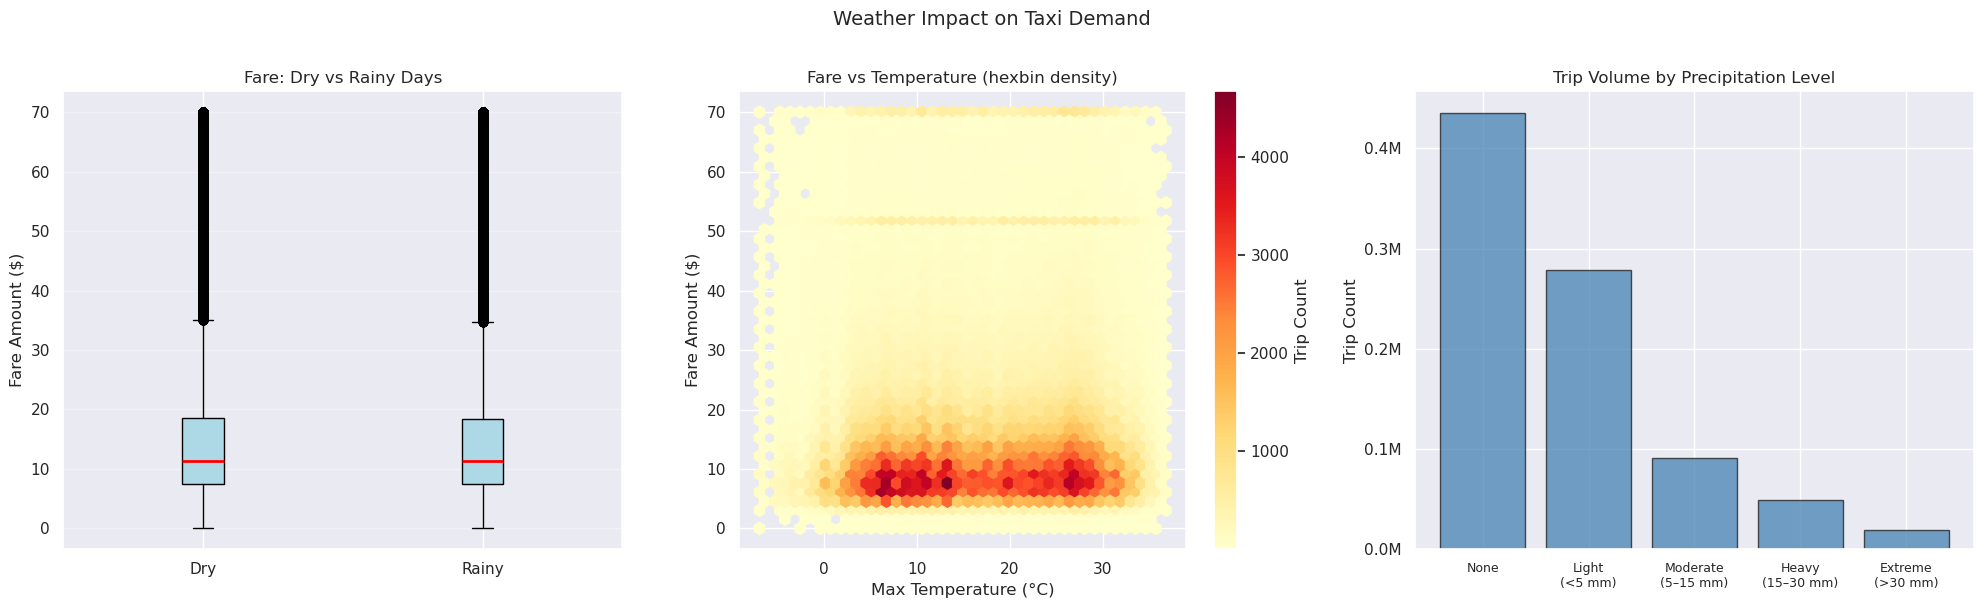

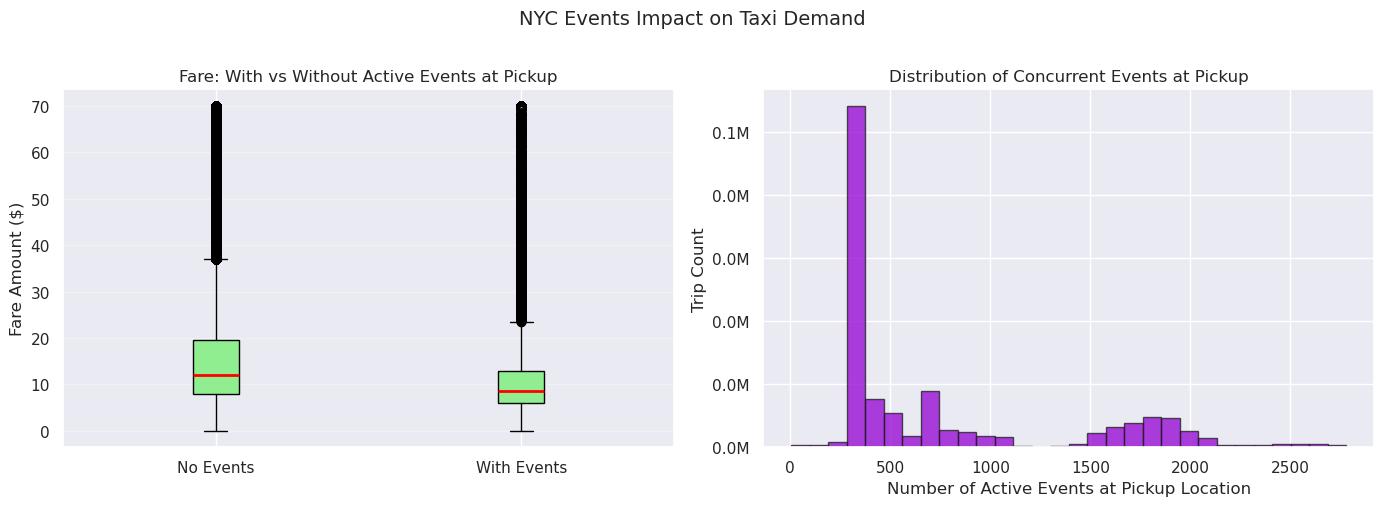

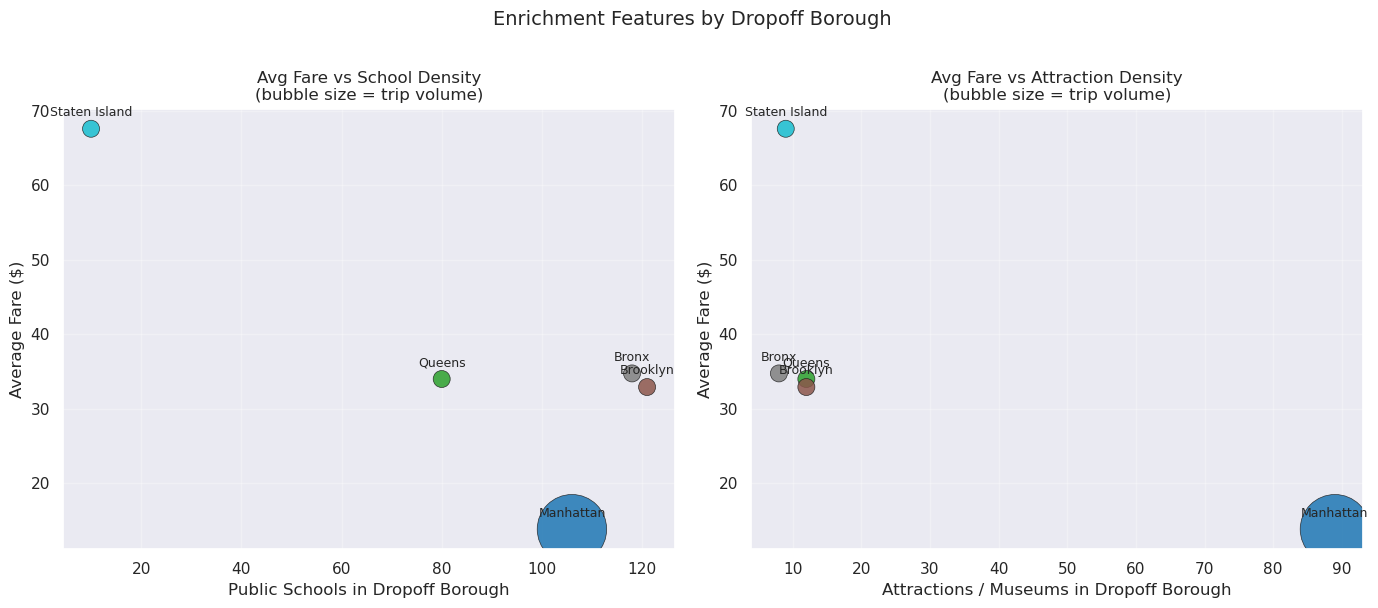

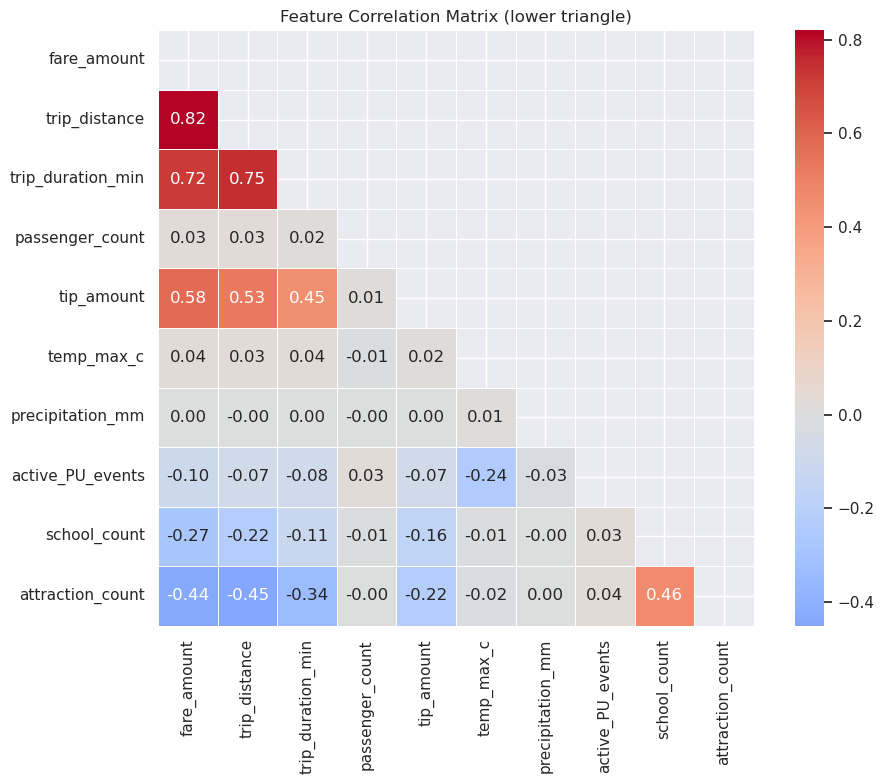

In [ ]:
# Weather impact
weather = df.groupby(df["precipitation_mm"] > 0).agg(...).compute()

# Events impact
events = df.groupby(df["active_PU_events"] > 0).agg(...).compute()


**Weather breakdown (Rainy vs Dry):**

In [ ]:
ew

,rainy,trips,avg_fare,avg_distance
0,Dry,86886505,16.41,3.32
1,Rainy,87596992,16.23,3.31


**Event activity breakdown:**

In [ ]:
ee

,has_event,trips,avg_fare,avg_distance
0,With events,22830838,11.28,2.47
1,No events,151652659,17.08,3.44


**Observations:**
- Rain has almost **no effect** on demand (rainy days: 87.6 M trips; dry: 86.9 M) or
  average fare — weather does not shift demand in a city where taxis compete with the subway.
- **Event presence** is associated with lower fares ($11.28 vs $17.08) and shorter distances
  (2.47 vs 3.44 miles): events concentrate short-haul trips in dense areas like Midtown and
  Downtown Manhattan.
- The correlation heatmap shows `fare_amount` and `total_amount` are highly correlated (0.96),
  and both correlate moderately with `trip_distance` (0.62) and `trip_duration_min` (0.58).
- Tip rate correlates weakly with fare — tipping behaviour is relatively flat across trip prices.


---
## 3  DuckDB Analysis

DuckDB was used as an in-process OLAP engine — no server required, queries run
directly against the Parquet files on disk.  It supports recursive glob patterns
so the entire Hive-partitioned dataset can be queried as a single virtual table.


In [ ]:
import duckdb

con = duckdb.connect()
con.execute("""
    CREATE VIEW trips AS
    SELECT * FROM read_parquet(
        '/d/hpc/.../parquet_augmented/year=2024/*.parquet'
    )
""")

# Q1 — hourly demand
con.execute("""
    SELECT hour(tpep_pickup_datetime)   AS pickup_hour,
           COUNT(*)                     AS trips,
           AVG(fare_amount)             AS avg_fare
    FROM   trips
    GROUP  BY pickup_hour
    ORDER  BY pickup_hour
""").df()


In [ ]:
# Q2 — borough stats
con.execute("""
    SELECT Borough_PU,
           COUNT(*)          AS trips,
           AVG(fare_amount)  AS avg_fare,
           AVG(trip_distance) AS avg_distance
    FROM   trips
    GROUP  BY Borough_PU
    ORDER  BY trips DESC
""").df()


In [ ]:
# Q5 — top 10 pickup zones
con.execute("""
    SELECT Zone_PU, COUNT(*) AS trips
    FROM   trips
    WHERE  Zone_PU IS NOT NULL
    GROUP  BY Zone_PU
    ORDER  BY trips DESC
    LIMIT  10
""").df()


DuckDB parses the Parquet column metadata and only reads the columns referenced
in each query (column pruning), skipping row-groups that cannot contain matching
rows (predicate pushdown). This is why it outperforms Pandas and Dask for
analytical queries at this scale.


---
## 4  Performance Benchmarking

### Setup

All six library × format combinations were run on the **same data**:
Yellow Taxi 2024 (~41 M rows, 12 partitions).

| Format | Size on disk | Rows |
|---|---|---|
| Parquet (`year=2024/`) | 938 MB | 41,169,720 |
| CSV (`data_2024.csv`)  | 8.9 GB | 41,169,720 |

**Protocol:**
- Pandas / DuckDB: each query timed **3×**; median reported.
- Dask DataFrame: each query timed **once** (full distributed scan per call).
- Data load / connection setup is **not** included in query times.
- Dask SQL was skipped — `dask-sql` not available in the cluster environment.


### Results

In [ ]:
bpivot

query            Total (s)  ...  Q5: Top 10 pickup zones
library format              ...                         
Dask    CSV         141.22  ...                   20.633
        Parquet      40.51  ...                    1.625
DuckDB  CSV          23.90  ...                    4.496
        Parquet       1.29  ...                    0.083
Pandas  CSV          12.99  ...                    1.613
        Parquet      22.78  ...                    3.702

[6 rows x 6 columns]

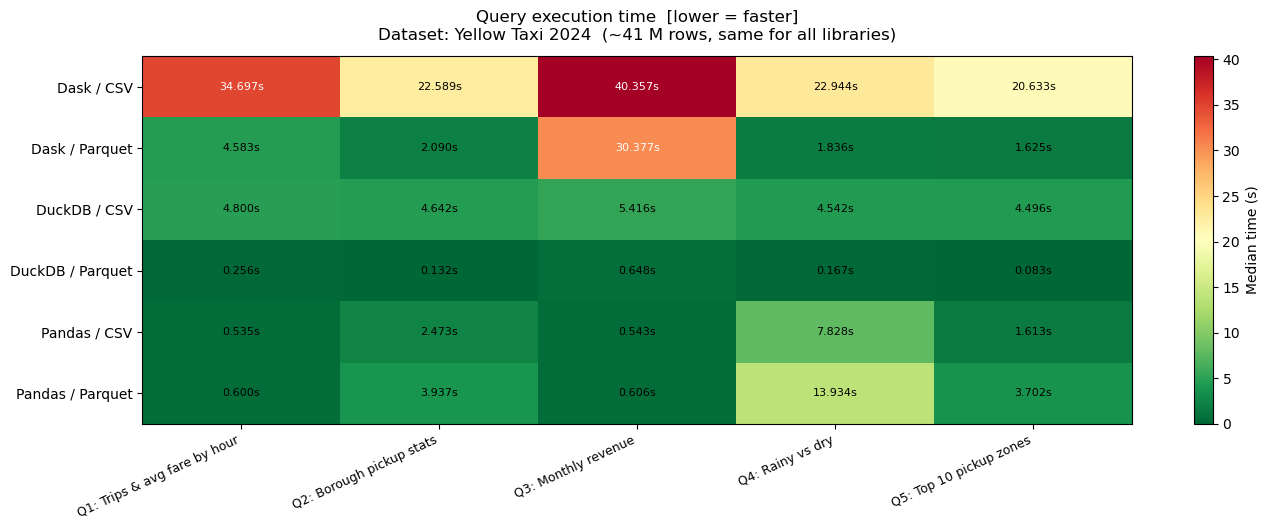

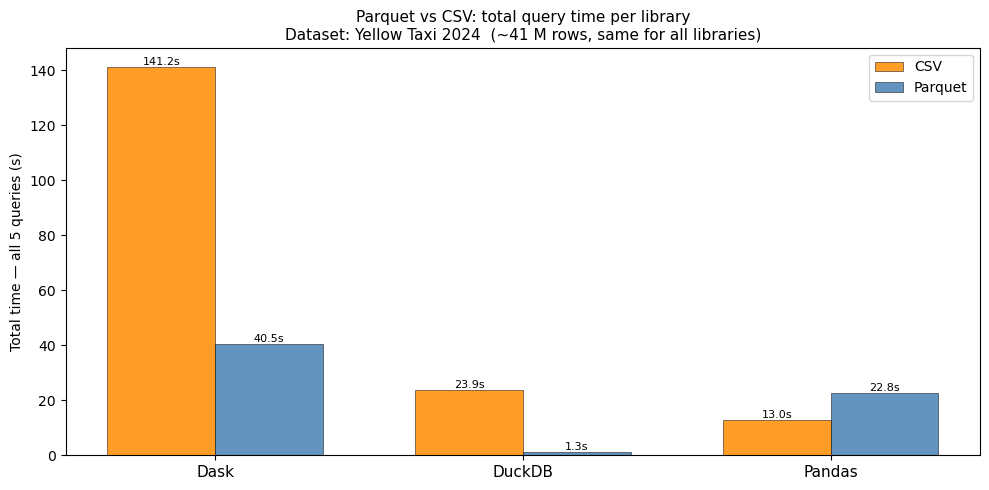

In [ ]:
# Benchmark timing helper
def timed(fn, n=N_RUNS):
    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        fn()
        times.append(time.perf_counter() - t0)
    return float(np.median(times))

# DuckDB — setup once, then time queries
con = duckdb.connect()
con.execute(f"CREATE VIEW trips AS SELECT * FROM read_parquet('{src}')")
for sql in DUCKDB_SQL:
    t = timed(lambda s=sql: con.execute(s).df())

# Dask — each compute() re-reads from disk (n=1)
ddf = dd.read_parquet(parquet_path)
ddf = ddf.assign(pickup_hour=ddf["tpep_pickup_datetime"].dt.hour)
for fn in DASK_FUNS:
    t = timed(lambda f=fn, d=ddf: f(d), n=1)
